# Pre-Draft Win Prediction

Predicts the outcome of professional LoL matches **before champion select** — purely from team identity and historical performance.

Three stages, evaluated on the same chronological test set:

| Stage | Model | Key signal |
|---|---|---|
| Baseline | Elo win probability | Team rating difference |
| Baseline+ | Elo + rolling features (XGBoost) | Elo + recent form |
| Full | Match Graph GNN | Learned team embeddings from win/loss graph |

**Re-run control:** set `FORCE_RETRAIN = True` below to retrain everything from scratch.

In [1]:
import sys, os, pickle
from pathlib import Path
sys.path.append(os.path.abspath("../src"))
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from data.oracleselixir import load_raw, build_game_df, build_vocabularies, load_and_cache
from models.elo import EloSystem, PlayerEloSystem, LeagueEloSystem
from models.match_gnn import build_match_graph, PreDraftPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SAVE_DIR = Path("../models/predraft")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

ELO_PATH    = SAVE_DIR / "elo_ratings.pkl"
XGB_PATH    = SAVE_DIR / "xgb_model.joblib"
LGBM_PATH   = SAVE_DIR / "lgbm_model.joblib"
TABPFN_PATH = SAVE_DIR / "tabpfn_model.joblib"
META_PATH   = SAVE_DIR / "meta_learner.joblib"
GNN_PATH    = SAVE_DIR / "gnn_weights.pt"
VOC_PATH    = SAVE_DIR / "team2idx.pkl"

FORCE_RETRAIN = True

Device: cuda


## 1. Load Data

In [2]:
game_df = load_and_cache(
    csv_dir    = "../src/data/oracleselixir",
    cache_path = "../src/data/game_df_cache.parquet",
    force_rebuild = FORCE_RETRAIN,
)

# Playoffs flag — merge from raw if not already in cache
if "is_playoffs" not in game_df.columns:
    raw = load_raw("../src/data/oracleselixir", complete_only=True)
    if "playoffs" in raw.columns:
        playoff_map = raw.drop_duplicates("gameid").set_index("gameid")["playoffs"]
        game_df["is_playoffs"] = game_df["gameid"].map(playoff_map).fillna(0).astype(int)
    else:
        game_df["is_playoffs"] = 0
    game_df.to_parquet("../src/data/game_df_cache.parquet", index=False)

game_df = game_df.sort_values("date").reset_index(drop=True)

print(f"Total games: {len(game_df):,}")
print(f"Date range:  {game_df['date'].min().date()} → {game_df['date'].max().date()}")
game_df[["date", "league", "blue_team", "red_team", "blue_win", "is_playoffs"]].head(5)

Building game_df from 7 CSV file(s)…
Built and cached 62,374 games → ../src/data/game_df_cache.parquet
Total games: 62,374
Date range:  2020-01-03 → 2026-05-01


,date,league,blue_team,red_team,blue_win,is_playoffs
0,2020-01-03 07:33:26,KeSPA,Liiv SANDBOX,T1,1,0
1,2020-01-03 09:00:58,KeSPA,T1,Liiv SANDBOX,0,0
2,2020-01-03 10:05:17,KeSPA,T1,Liiv SANDBOX,1,0
3,2020-01-03 10:57:28,KeSPA,T1,Liiv SANDBOX,0,0
4,2020-01-04 05:33:33,KeSPA,DRX,DN SOOPers,0,0


## 2. Elo Features (no leakage — ratings update after each annotation)

In [3]:
elo        = EloSystem()
player_elo = PlayerEloSystem()
league_elo = LeagueEloSystem()

if not FORCE_RETRAIN and ELO_PATH.exists():
    with open(ELO_PATH, "rb") as f:
        saved = pickle.load(f)
    elo._ratings     = saved["ratings"]
    elo._games       = saved["games"]
    elo._blue_wins   = saved.get("blue_wins",  elo._blue_wins)
    elo._blue_games  = saved.get("blue_games", elo._blue_games)
    elo._red_wins    = saved.get("red_wins",   elo._red_wins)
    elo._red_games   = saved.get("red_games",  elo._red_games)
    elo._h2h.update(saved.get("h2h", {}))
    for k, v in saved.get("elo_hist", {}).items():
        from collections import deque
        elo._elo_hist[k] = deque(v, maxlen=5)
    player_elo._ratings = saved.get("player_ratings", {})
    for lg, entries in saved.get("league_elo_updates", {}).items():
        from collections import deque
        league_elo._updates[lg] = deque(
            [(pd.Timestamp(dt), delta) for dt, delta in entries]
        )
    print(f"Loaded Elo ratings from {ELO_PATH}  ({len(elo._ratings)} teams)")

# Always re-annotate game_df so elo_diff / elo_win_prob columns are present
game_df = elo.process_and_annotate(game_df, min_games=5, player_elo=player_elo, league_elo=league_elo)

print(f"Cold-start games (excluded from eval): {game_df['cold_start'].sum()}")
print(f"Evaluable games:                        {(~game_df['cold_start']).sum()}")
game_df[["blue_team", "red_team", "elo_diff", "elo_win_prob",
         "blue_recent_wr", "red_recent_wr", "blue_side_wr", "red_side_wr", "h2h_wr", "cold_start"]].head(10)

Cold-start games (excluded from eval): 6264
Evaluable games:                        56110


,blue_team,red_team,elo_diff,elo_win_prob,blue_recent_wr,red_recent_wr,blue_side_wr,red_side_wr,h2h_wr,cold_start
0,Liiv SANDBOX,T1,0.000000,0.521573,0.500000,0.500000,0.5,0.500000,0.5,True
1,T1,Liiv SANDBOX,-9.185792,0.508367,0.000000,1.000000,0.5,0.500000,0.5,True
2,T1,Liiv SANDBOX,-18.946430,0.494321,0.000000,1.000000,0.0,1.000000,0.0,True
3,T1,Liiv SANDBOX,-9.237390,0.508292,0.333333,0.666667,0.5,0.500000,0.5,True
4,DRX,DN SOOPers,0.000000,0.521573,0.500000,0.500000,0.5,0.500000,0.5,True
5,DN SOOPers,DRX,10.014208,0.535936,1.000000,0.000000,0.5,0.500000,0.5,True
6,DN SOOPers,DRX,18.924232,0.548666,1.000000,0.000000,1.0,0.000000,1.0,True
7,Liiv SANDBOX,DN SOOPers,-4.296618,0.515399,0.750000,1.000000,1.0,1.000000,0.5,True
8,DN SOOPers,Liiv SANDBOX,14.192270,0.541912,1.000000,0.600000,1.0,0.666667,0.5,True
9,Liiv SANDBOX,DN SOOPers,-22.987550,0.488507,0.500000,1.000000,0.5,1.000000,0.0,False


## 3. Chronological Train / Val / Test Split

In [4]:
n       = len(game_df)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

train_df = game_df.iloc[:n_train].reset_index(drop=True)
val_df   = game_df.iloc[n_train:n_val].reset_index(drop=True)
test_df  = game_df.iloc[n_val:].reset_index(drop=True)

# Evaluable subsets (exclude cold-start for fair comparison)
eval_test = test_df[~test_df["cold_start"]].reset_index(drop=True)

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"Evaluable test games: {len(eval_test):,}")
print(f"Test period: {test_df['date'].min().date()} → {test_df['date'].max().date()}")

Train: 43,661  |  Val: 9,356  |  Test: 9,357
Evaluable test games: 8,646
Test period: 2025-04-29 → 2026-05-01


## 4. Baseline A — Elo Win Probability (threshold at 0.5)

=== Elo Baseline ===
Accuracy:  0.625
ROC AUC:   0.671
Log loss:  0.6498


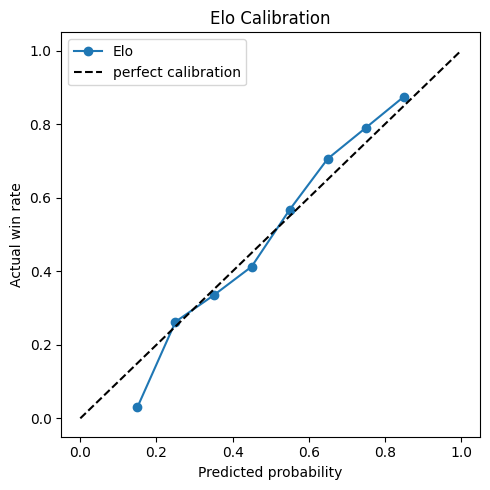

In [5]:
y_true      = eval_test["blue_win"].values
elo_proba   = eval_test["elo_win_prob"].values
elo_pred    = (elo_proba > 0.5).astype(int)

print("=== Elo Baseline ===")
print(f"Accuracy:  {accuracy_score(y_true, elo_pred):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_true, elo_proba):.3f}")
print(f"Log loss:  {log_loss(y_true, elo_proba):.4f}")

# Calibration check
bins = np.linspace(0, 1, 11)
bin_centers, bin_acc = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (elo_proba >= lo) & (elo_proba < hi)
    if mask.sum() > 5:
        bin_centers.append((lo + hi) / 2)
        bin_acc.append(y_true[mask].mean())

plt.figure(figsize=(5, 5))
plt.plot(bin_centers, bin_acc, marker="o", label="Elo")
plt.plot([0, 1], [0, 1], "k--", label="perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Actual win rate")
plt.title("Elo Calibration")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Baseline B — Elo + Recent Form (XGBoost)

In [6]:
FEATURE_COLS = [
    "elo_diff",
    "blue_ewma_wr", "red_ewma_wr",
    "is_playoffs",
    "blue_elo_momentum", "red_elo_momentum",
    # Per-role player Elos
    "blue_top_elo", "blue_jng_elo", "blue_mid_elo", "blue_bot_elo", "blue_sup_elo",
    "red_top_elo",  "red_jng_elo",  "red_mid_elo",  "red_bot_elo",  "red_sup_elo",
    # Competition tier: 1=LCK/LPL, 2=LEC/LTA N, 3=regional, 4=default
    # Lets models learn that same Elo diff means different things in different leagues
    "league_tier",
    # Games played confidence (0→1, saturates at 200 games).
    # Lets model discount predictions for new/provisional teams.
    "blue_games_conf", "red_games_conf",
]
# 19 features total → CONTEXT_DIM = 19 in match_gnn.py

train_eval = train_df[~train_df["cold_start"]]
val_eval   = val_df[~val_df["cold_start"]]

X_train = train_eval[FEATURE_COLS].values.astype(np.float32)
y_train = train_eval["blue_win"].values
X_val   = val_eval[FEATURE_COLS].values.astype(np.float32)
y_val   = val_eval["blue_win"].values
X_test  = eval_test[FEATURE_COLS].values.astype(np.float32)

# ── Helper: blue/red flip augmentation ──────────────────────────────────────
# Swap all blue_* ↔ red_* features; negate elo_diff; invert label.
# Indices: 0=elo_diff, 1=b_ewma, 2=r_ewma, 3=playoffs, 4=b_mom, 5=r_mom,
#          6-10=blue role Elos, 11-15=red role Elos
def flip_augment(X, y):
    Xf = X.copy()
    Xf[:, 0]    = -X[:, 0]       # negate elo_diff
    Xf[:, 1]    = X[:, 2]        # blue_ewma ← red_ewma
    Xf[:, 2]    = X[:, 1]        # red_ewma  ← blue_ewma
    # col 3 (is_playoffs) unchanged
    Xf[:, 4]    = X[:, 5]        # blue_momentum ← red_momentum
    Xf[:, 5]    = X[:, 4]        # red_momentum  ← blue_momentum
    Xf[:, 6:11] = X[:, 11:16]    # blue role Elos ← red role Elos
    Xf[:, 11:16]= X[:, 6:11]     # red role Elos  ← blue role Elos
    Xf[:, 17]   = X[:, 18];  Xf[:, 18] = X[:, 17]  # games_conf
    return np.vstack([X, Xf]), np.concatenate([y, 1 - y])

X_train_aug, y_train_aug = flip_augment(X_train, y_train)
print(f"Training samples: {len(X_train):,} → {len(X_train_aug):,} (after flip augmentation)")

# ── XGBoost (kept as baseline reference) ────────────────────────────────────
if not FORCE_RETRAIN and XGB_PATH.exists():
    xgb = joblib.load(XGB_PATH)
    print(f"Loaded XGBoost from {XGB_PATH}")
else:
    xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                        subsample=0.8, eval_metric="logloss", verbosity=0)
    xgb.fit(X_train_aug, y_train_aug, eval_set=[(X_val, y_val)], verbose=False)
    joblib.dump(xgb, XGB_PATH)
    print(f"Saved XGBoost -> {XGB_PATH}")

xgb_proba = xgb.predict_proba(X_test)[:, 1]
print(f"XGBoost  AUC: {roc_auc_score(y_true, xgb_proba):.4f}")

# ── LightGBM ─────────────────────────────────────────────────────────────────
if not FORCE_RETRAIN and LGBM_PATH.exists():
    lgbm = joblib.load(LGBM_PATH)
    print(f"Loaded LightGBM from {LGBM_PATH}")
else:
    lgbm = LGBMClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.03,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=20, verbose=-1,
    )
    lgbm.fit(
        X_train_aug, y_train_aug,
        eval_set=[(X_val, y_val)],
        callbacks=[],
    )
    joblib.dump(lgbm, LGBM_PATH)
    print(f"Saved LightGBM -> {LGBM_PATH}")

lgbm_proba = lgbm.predict_proba(X_test)[:, 1]
print(f"LightGBM AUC: {roc_auc_score(y_true, lgbm_proba):.4f}")

# ── Feature importance ───────────────────────────────────────────────────────
print("\nLightGBM feature importances:")
for name, imp in sorted(zip(FEATURE_COLS, lgbm.feature_importances_), key=lambda x: -x[1]):
    print(f"  {name:<30} {imp}")

Training samples: 39,032 → 78,064 (after flip augmentation)
Saved XGBoost -> ../models/predraft/xgb_model.joblib
XGBoost  AUC: 0.7004
Saved LightGBM -> ../models/predraft/lgbm_model.joblib
LightGBM AUC: 0.6985

LightGBM feature importances:
  elo_diff                       1026
  blue_bot_elo                   962
  blue_ewma_wr                   942
  red_bot_elo                    922
  blue_jng_elo                   893
  blue_sup_elo                   880
  red_ewma_wr                    874
  red_mid_elo                    870
  blue_mid_elo                   859
  red_top_elo                    835
  blue_top_elo                   831
  red_sup_elo                    826
  red_jng_elo                    817
  red_elo_momentum               723
  blue_elo_momentum              714
  league_tier                    211
  is_playoffs                    78


/home/jan/projects/LoL/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 6. Match Graph GNN

The GNN runs over a graph of all training matches to learn team embeddings, then predicts using those embeddings + the same context features as XGBoost.

## 5b. TabPFN v2 + OOF Meta-Learner

**TabPFN** is a pretrained transformer that does in-context learning on tabular data — no gradient updates, just a forward pass. We include it as a 4th base model in the stack.

**OOF stacking strategy (temporal):**
- Base models (XGBoost, LightGBM) are trained on the train split and predict on the val split → those val predictions are the OOF inputs for the meta-learner
- GNN and Elo predictions on the val split are used similarly
- Meta-learner: Logistic Regression on `[elo, xgb, lgbm, gnn, tabpfn]` val predictions → learns optimal linear combination
- Final ensemble uses the meta-learner on test-set model outputs

In [7]:
import os
from pathlib import Path
_env = Path("../.env")
if _env.exists():
    for _line in _env.read_text().splitlines():
        _line = _line.strip()
        if _line and not _line.startswith("#") and "=" in _line:
            _k, _v = _line.split("=", 1)
            os.environ[_k.strip()] = _v.strip().strip('"').strip("'")

_tok = os.environ.get("TABPFN_TOKEN", "")
if _tok:
    print(f"TABPFN_TOKEN is set ({len(_tok)} chars)")
else:
    print("WARNING: TABPFN_TOKEN is NOT set — TabPFN will fail.")

try:
    from tabpfn import TabPFNClassifier

    if not FORCE_RETRAIN and TABPFN_PATH.exists():
        tabpfn = joblib.load(TABPFN_PATH)
        print(f"Loaded TabPFN from {TABPFN_PATH}")
    else:
        tabpfn = TabPFNClassifier(device="cuda" if torch.cuda.is_available() else "cpu")
        # TabPFN fits on training data (may subsample internally for large N)
        tabpfn.fit(X_train, y_train)
        joblib.dump(tabpfn, TABPFN_PATH)
        print(f"Saved TabPFN -> {TABPFN_PATH}")

    tabpfn_proba = tabpfn.predict_proba(X_test)[:, 1]
    print(f"TabPFN   AUC: {roc_auc_score(y_true, tabpfn_proba):.4f}")
    TABPFN_AVAILABLE = True

except Exception as e:
    print(f"TabPFN unavailable ({e}) — skipping. Install with: uv add tabpfn")
    tabpfn       = None
    tabpfn_proba = None
    TABPFN_AVAILABLE = False

# ── OOF validation predictions for meta-learner ──────────────────────────────
# Val split is our "held-out" OOF set for stacking.
X_val_arr = val_eval[FEATURE_COLS].values.astype(np.float32)
y_val_arr = val_eval["blue_win"].values

elo_val_proba  = val_eval["elo_win_prob"].values   # already zero-leakage
xgb_val_proba  = xgb.predict_proba(X_val_arr)[:, 1]
lgbm_val_proba = lgbm.predict_proba(X_val_arr)[:, 1]

# GNN val predictions (uses train_graph + model trained on train set)
def gnn_predict(df_eval, model, graph):
    model.eval()
    bi  = torch.tensor([team2idx.get(t, 0) for t in df_eval["blue_team"]], dtype=torch.long, device=device)
    ri  = torch.tensor([team2idx.get(t, 0) for t in df_eval["red_team"]],  dtype=torch.long, device=device)
    ctx = torch.tensor(df_eval[FEATURE_COLS].values, dtype=torch.float, device=device)
    with torch.no_grad():
        emb  = model.encode_all_teams(graph)
        prob = model(emb, bi, ri, ctx).cpu().numpy()
    return prob

gnn_val_proba = None

if TABPFN_AVAILABLE:
    tabpfn_val_proba = tabpfn.predict_proba(X_val_arr)[:, 1]
else:
    tabpfn_val_proba = None

print("OOF val probabilities computed (GNN will be added after training in Section 6)")

TABPFN_TOKEN is set (167 chars)
Saved TabPFN -> ../models/predraft/tabpfn_model.joblib
TabPFN   AUC: 0.7029


/home/jan/projects/LoL/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF val probabilities computed (GNN will be added after training in Section 6)


In [8]:
_, team2idx, _ = build_vocabularies(game_df)

train_graph = build_match_graph(train_df, team2idx, halflife_days=180, max_repeats=5)
train_graph = train_graph.to(device)

print(f"Graph: {len(team2idx)+1} team nodes, {train_graph.edge_index.shape[1]} edges")

model = PreDraftPredictor(
    num_teams=len(team2idx),
    emb_dim=128,
    out_dim=64,
    hidden=128,
    dropout=0.2,
).to(device)

if not FORCE_RETRAIN and GNN_PATH.exists() and VOC_PATH.exists():
    with open(VOC_PATH, "rb") as f:
        team2idx = pickle.load(f)
    state = torch.load(GNN_PATH, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model = torch.compile(model)
    print(f"Loaded GNN weights from {GNN_PATH}  (skipping training)")
    SKIP_TRAINING = True
else:
    EPOCHS    = 150
    PATIENCE  = 20
    model     = torch.compile(model)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
    SKIP_TRAINING = False

print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Graph: 1790 team nodes, 117982 edges
Parameters: 364,993


In [9]:
def df_to_tensors(df, team2idx, device, augment=False):
    """Convert a game dataframe to tensors for the GNN predictor."""
    blue_idx = [team2idx.get(t, 0) for t in df["blue_team"]]
    red_idx  = [team2idx.get(t, 0) for t in df["red_team"]]
    ctx_np   = df[FEATURE_COLS].values.astype(np.float32)
    labels_np = df["blue_win"].values.astype(np.float32)

    if augment:
        # Blue/red flip: swap team indices + context features + invert label
        ctx_flip = ctx_np.copy()
        ctx_flip[:, 0]    = -ctx_np[:, 0]       # negate elo_diff
        ctx_flip[:, 1]    = ctx_np[:, 2]         # swap ewma_wr
        ctx_flip[:, 2]    = ctx_np[:, 1]
        ctx_flip[:, 4]    = ctx_np[:, 5]         # swap momentum
        ctx_flip[:, 5]    = ctx_np[:, 4]
        ctx_flip[:, 6:11] = ctx_np[:, 11:16]     # swap role Elos
        ctx_flip[:, 11:16]= ctx_np[:, 6:11]
        ctx_flip[:, 17]   = ctx_np[:, 18]         # swap games_conf
        ctx_flip[:, 18]   = ctx_np[:, 17]
        blue_idx  = blue_idx  + red_idx
        red_idx   = red_idx   + [team2idx.get(t, 0) for t in df["blue_team"]]
        ctx_np    = np.vstack([ctx_np, ctx_flip])
        labels_np = np.concatenate([labels_np, 1 - labels_np])

    return (
        torch.tensor(blue_idx,  dtype=torch.long,  device=device),
        torch.tensor(red_idx,   dtype=torch.long,  device=device),
        torch.tensor(ctx_np,    dtype=torch.float, device=device),
        torch.tensor(labels_np, dtype=torch.float, device=device),
    )


def run_epoch(df, train=False, batch_size=128, augment=False):
    model.train() if train else model.eval()

    with torch.set_grad_enabled(train):
        team_emb = model.encode_all_teams(train_graph)

    blue_idx, red_idx, context, labels = df_to_tensors(df, team2idx, device, augment=augment)

    total_loss, all_proba, all_true = 0.0, [], []
    n = len(labels)

    for start in range(0, n, batch_size):
        bi = blue_idx[start:start+batch_size]
        ri = red_idx[start:start+batch_size]
        ct = context[start:start+batch_size]
        yt = labels[start:start+batch_size]

        with torch.set_grad_enabled(train):
            proba = model(team_emb, bi, ri, ct)
            loss  = F.binary_cross_entropy(proba, yt)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            team_emb = model.encode_all_teams(train_graph)

        total_loss += loss.item() * len(yt)
        all_proba.extend(proba.detach().cpu().tolist())
        all_true.extend(yt.cpu().tolist())

    all_proba = np.array(all_proba)
    all_true  = np.array(all_true)
    return {
        "loss": total_loss / n,
        "acc":  accuracy_score(all_true, all_proba > 0.5),
        "auc":  roc_auc_score(all_true, all_proba),
        "proba": all_proba,
    }


if not SKIP_TRAINING:
    best_val_loss  = float("inf")
    patience_count = 0
    history = {"train": [], "val": []}
    train_eval_df = train_df[~train_df["cold_start"]].reset_index(drop=True)
    val_eval_df   = val_df[~val_df["cold_start"]].reset_index(drop=True)
    BEST_CKPT = SAVE_DIR / "_best_gnn_ckpt.pt"

    for epoch in range(1, EPOCHS + 1):
        tr = run_epoch(train_eval_df, train=True, augment=True)
        vl = run_epoch(val_eval_df,   train=False)
        scheduler.step()
        history["train"].append(tr)
        history["val"].append(vl)

        is_best = vl["loss"] < best_val_loss
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | "
                  f"train loss {tr['loss']:.4f}  acc {tr['acc']:.3f}  auc {tr['auc']:.3f} | "
                  f"val   loss {vl['loss']:.4f}  acc {vl['acc']:.3f}  auc {vl['auc']:.3f}"
                  + ("  <- best" if is_best else ""))

        if is_best:
            best_val_loss = vl["loss"]
            patience_count = 0
            raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model
            torch.save(raw_model.state_dict(), BEST_CKPT)
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"Early stopping at epoch {epoch}  (best val loss {best_val_loss:.4f}  patience {PATIENCE})")
                break

    # Restore best checkpoint
    state = torch.load(BEST_CKPT, map_location=device, weights_only=True)
    raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model
    raw_model.load_state_dict(state)
    print(f"Restored best checkpoint (val loss {best_val_loss:.4f})")

    # ── GNN val predictions for meta-learner ────────────────────────────────
    gnn_val_proba = gnn_predict(val_eval_df, raw_model, train_graph)
    print(f"GNN val AUC: {roc_auc_score(y_val_arr, gnn_val_proba):.4f}")

    # ── Meta-learner (Logistic Regression on OOF val predictions) ───────────
    # Stack: [elo, xgb, lgbm, gnn, tabpfn(if available)]
    meta_X_val = np.column_stack([
        elo_val_proba,
        xgb_val_proba,
        lgbm_val_proba,
        gnn_val_proba,
        tabpfn_val_proba if tabpfn_val_proba is not None else lgbm_val_proba,
    ])
    meta = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs")
    meta.fit(meta_X_val, y_val_arr)
    print(f"Meta-learner weights: {dict(zip(['elo','xgb','lgbm','gnn','tabpfn'], meta.coef_[0].round(3)))}")

    # ── Save all models ──────────────────────────────────────────────────────
    torch.save(state, GNN_PATH)
    with open(VOC_PATH, "wb") as f:
        pickle.dump(team2idx, f)
    with open(ELO_PATH, "wb") as f:
        pickle.dump({
            "ratings":       elo._ratings,
            "games":         elo._games,
            "blue_wins":     dict(elo._blue_wins),
            "blue_games":    dict(elo._blue_games),
            "red_wins":      dict(elo._red_wins),
            "red_games":     dict(elo._red_games),
            "h2h":           dict(elo._h2h),
            "elo_hist":      {k: list(v) for k, v in elo._elo_hist.items()},
            "player_ratings": dict(player_elo._ratings),
            "league_elo_updates": {
                lg: [(str(dt), delta) for dt, delta in entries]
                for lg, entries in league_elo._updates.items()
            },
        }, f)
    joblib.dump(xgb,  XGB_PATH)
    joblib.dump(lgbm, LGBM_PATH)
    joblib.dump(meta, META_PATH)
    if TABPFN_AVAILABLE:
        joblib.dump(tabpfn, TABPFN_PATH)
    BEST_CKPT.unlink(missing_ok=True)
    print(f"Saved GNN      -> {GNN_PATH}")
    print(f"Saved team2idx -> {VOC_PATH}")
    print(f"Saved Elo      -> {ELO_PATH}")
    print(f"Saved XGBoost  -> {XGB_PATH}")
    print(f"Saved LightGBM -> {LGBM_PATH}")
    print(f"Saved meta     -> {META_PATH}")
else:
    print("Skipped training (loaded from disk). Set FORCE_RETRAIN=True to retrain.")
    gnn_val_proba = gnn_predict(val_eval_df, model, train_graph)

/home/jan/projects/LoL/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


Epoch   1 | train loss 3.6473  acc 0.532  auc 0.537 | val   loss 0.6632  acc 0.650  auc 0.702  <- best
Epoch  10 | train loss 0.6173  acc 0.660  auc 0.718 | val   loss 0.6878  acc 0.629  auc 0.673
Epoch  20 | train loss 0.6084  acc 0.666  auc 0.728 | val   loss 0.7078  acc 0.624  auc 0.664
Early stopping at epoch 23  (best val loss 0.6295  patience 20)
Restored best checkpoint (val loss 0.6295)
GNN val AUC: 0.7061
Meta-learner weights: {'elo': np.float64(-0.996), 'xgb': np.float64(1.531), 'lgbm': np.float64(0.843), 'gnn': np.float64(0.467), 'tabpfn': np.float64(2.44)}
Saved GNN      -> ../models/predraft/gnn_weights.pt
Saved team2idx -> ../models/predraft/team2idx.pkl
Saved Elo      -> ../models/predraft/elo_ratings.pkl
Saved XGBoost  -> ../models/predraft/xgb_model.joblib
Saved LightGBM -> ../models/predraft/lgbm_model.joblib
Saved meta     -> ../models/predraft/meta_learner.joblib


## 7. Results Comparison

                      accuracy  roc_auc   brier  log_loss
model                                                    
Elo (baseline)          0.6248   0.6706  0.2291    0.6498
XGBoost                 0.6489   0.7004  0.2197    0.6294
LightGBM (aug)          0.6468   0.6985  0.2203    0.6310
Match Graph GNN         0.6428   0.6909  0.2239    0.6393
TabPFN v2               0.6499   0.7029  0.2183    0.6262
Meta-learner (stack)    0.6493   0.7035  0.2184    0.6263


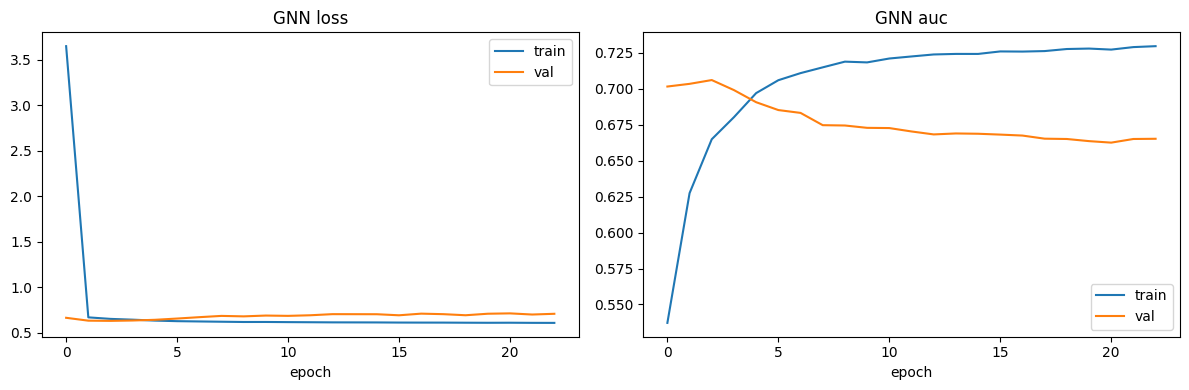


Meta-learner coefficients (positive = favours blue-win):
  Elo          -0.996
  XGBoost      +1.531
  LightGBM     +0.843
  GNN          +0.467
  TabPFN       +2.440


In [10]:
gnn_results = run_epoch(eval_test, train=False)
gnn_proba   = gnn_results["proba"]

# ── Meta-learner test predictions ────────────────────────────────────────────
meta_X_test = np.column_stack([
    elo_proba,
    xgb_proba,
    lgbm_proba,
    gnn_proba,
    tabpfn_proba if tabpfn_proba is not None else lgbm_proba,
])
meta_proba = meta.predict_proba(meta_X_test)[:, 1]

# ── Results table ─────────────────────────────────────────────────────────────
from sklearn.metrics import brier_score_loss

def _row(name, proba, y):
    return {"model": name,
            "accuracy":    round(accuracy_score(y, proba > 0.5), 4),
            "roc_auc":     round(roc_auc_score(y, proba), 4),
            "brier":       round(brier_score_loss(y, proba), 4),
            "log_loss":    round(log_loss(y, proba), 4)}

rows = [
    _row("Elo (baseline)",      elo_proba,   y_true),
    _row("XGBoost",             xgb_proba,   y_true),
    _row("LightGBM (aug)",      lgbm_proba,  y_true),
    _row("Match Graph GNN",     gnn_proba,   y_true),
    _row("Meta-learner (stack)", meta_proba, y_true),
]
if tabpfn_proba is not None:
    rows.insert(4, _row("TabPFN v2", tabpfn_proba, y_true))

results = pd.DataFrame(rows).set_index("model").round(4)
print(results.to_string())

# ── Learning curves ───────────────────────────────────────────────────────────
if not SKIP_TRAINING:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, key in zip(axes, ["loss", "auc"]):
        ax.plot([e[key] for e in history["train"]], label="train")
        ax.plot([e[key] for e in history["val"]],   label="val")
        ax.set_title(f"GNN {key}")
        ax.set_xlabel("epoch")
        ax.legend()
    plt.tight_layout()
    plt.show()

# ── Meta-learner weights ──────────────────────────────────────────────────────
print("\nMeta-learner coefficients (positive = favours blue-win):")
labels_meta = ["Elo", "XGBoost", "LightGBM", "GNN", "TabPFN"]
for name, coef in zip(labels_meta, meta.coef_[0]):
    print(f"  {name:<12} {coef:+.3f}")

## 9. Detailed Test-Set Analysis

Where does the model succeed and where does it fall short?

- **Confidence stratification** — accuracy at each confidence level (is 70% prediction actually 70% accurate?)
- **Per-league** — which leagues are hardest to predict?
- **Elo differential** — does model add value beyond pure Elo?
- **Playoffs vs regular season** — do upsets happen more in playoffs?
- **Temporal drift** — is accuracy stable across the test period?
- **Biggest upsets** — where was the model most confidently wrong?
- **SHAP feature importance** — what drives predictions most?


9a. Confidence stratification (meta-learner)
confidence  n_games  accuracy
   50%–55%     1334     0.517
   55%–60%     1422     0.569
   60%–65%     1503     0.608
   65%–70%     1344     0.664
      70%+     3043     0.759


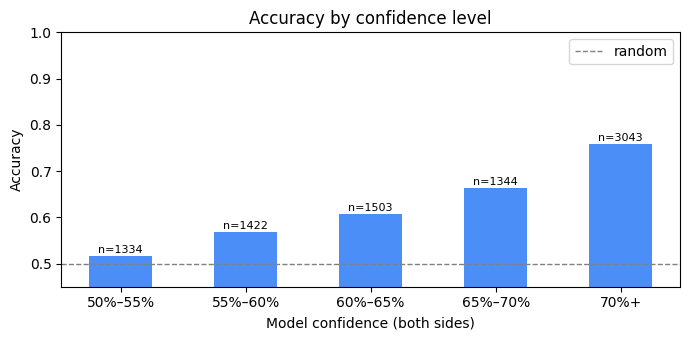


9b. Per-league performance (meta-learner, min 30 games)
     league  n_games  accuracy  roc_auc  brier  blue_wr
        NLC      151     0.775    0.855 0.1672    0.517
         HM      166     0.723    0.815 0.1839    0.488
      LPLOL       91     0.758    0.810 0.1929    0.538
       NEXO       52     0.750    0.805 0.1958    0.558
        HLL      192     0.750    0.797 0.1841    0.521
        EBL      190     0.716    0.793 0.1902    0.500
        PCS      156     0.705    0.790 0.1891    0.500
        LAS      478     0.713    0.784 0.1908    0.531
        LJL      379     0.699    0.781 0.1972    0.467
        ROL      221     0.683    0.777 0.1972    0.529
        LES       51     0.608    0.760 0.2073    0.490
        LIT      157     0.675    0.740 0.2130    0.497
        LCP      313     0.655    0.737 0.2067    0.550
        TCL      194     0.675    0.729 0.2053    0.572
         AL      348     0.652    0.729 0.2049    0.563
        LCK      568     0.669    0.723 0.2129 

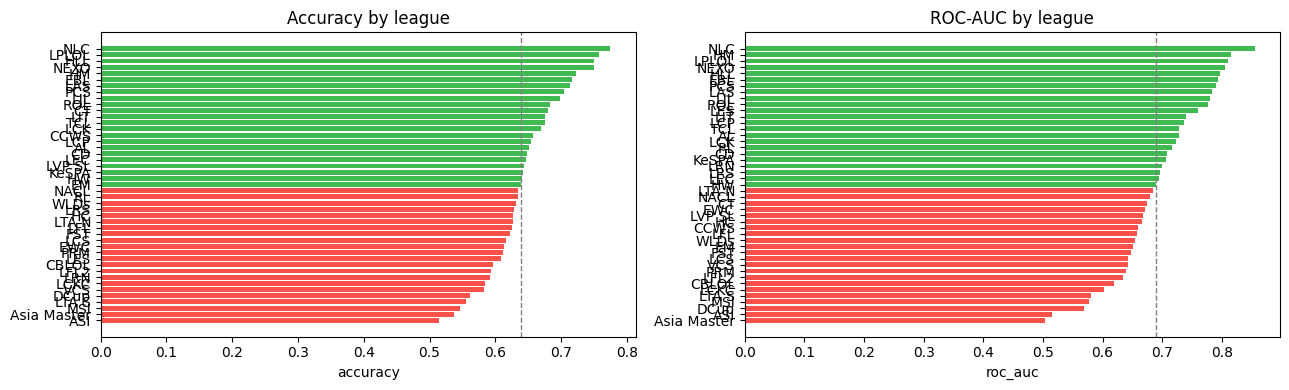


9c. Performance by Elo differential (quartiles)
elo_diff_range    quartile  n_games  elo_acc  meta_acc  meta_auc
          0–22    Q1 close     2162    0.524     0.581     0.623
         22–49          Q2     2161    0.602     0.631     0.678
         49–88          Q3     2161    0.636     0.646     0.690
        88–359 Q4 dominant     2162    0.736     0.740     0.781

If meta_acc > elo_acc in Q1 (close games), the model adds real signal beyond Elo.

9d. Playoffs vs Regular Season
  Regular season      n=6732  acc=0.654  auc=0.710  brier=0.2168
  Playoffs            n=1914  acc=0.634  auc=0.681  brier=0.2237

9e. Temporal drift — accuracy by month
  month    n  accuracy   auc
2025-04   94     0.649 0.741
2025-05 1418     0.668 0.726
2025-06  610     0.595 0.613
2025-07  768     0.658 0.718
2025-08 1154     0.652 0.710
2025-09  701     0.605 0.642
2025-10  501     0.627 0.660
2025-11   92     0.728 0.756
2025-12  119     0.597 0.643
2026-01  451     0.650 0.704
2026-02  805     0.640

/tmp/ipykernel_31670/4233249350.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_month["month"], rotation=45, ha="right")


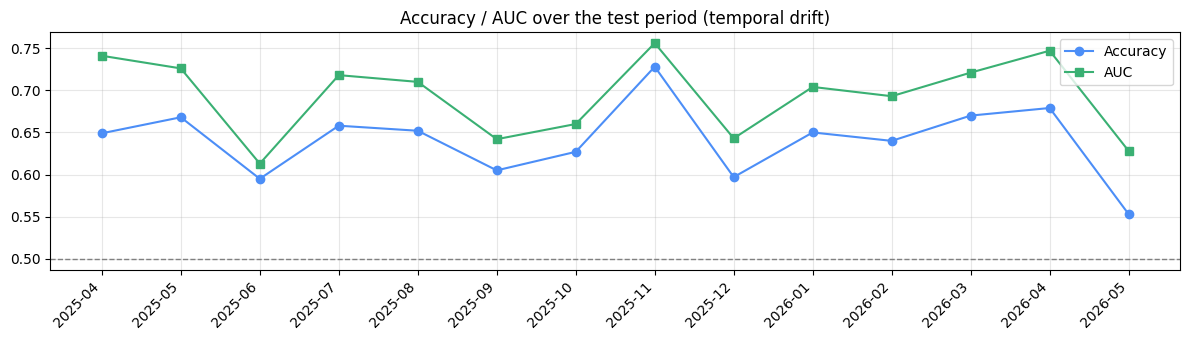


9f. Top-20 biggest upsets (model most confident, most wrong)
               date      league                   blue_team                                red_team  pred_prob  blue_win    elo_diff  is_playoffs
2025-05-17 11:00:48        LFL2               Esprit Shōnen                 Karmine Corp Blue Stars   0.885587         0   93.364123            0
2026-04-09 05:50:55        LCKC          T1 Esports Academy                    Gen.G Global Academy   0.882608         0  170.867321            0
2025-09-10 19:41:15         EBL             The Secret Club                    Lenovo Legion Honvéd   0.880384         0   59.440943            0
2025-08-17 11:04:32        LFL2               Caldya Esport                 Karmine Corp Blue Stars   0.878661         0   60.706428            0
2025-10-05 17:45:23         NLC                         LEO                            KAOS e-sport   0.871732         0  121.728906            0
2026-04-08 18:46:43          RL                    Forsaken   

/home/jan/projects/LoL/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


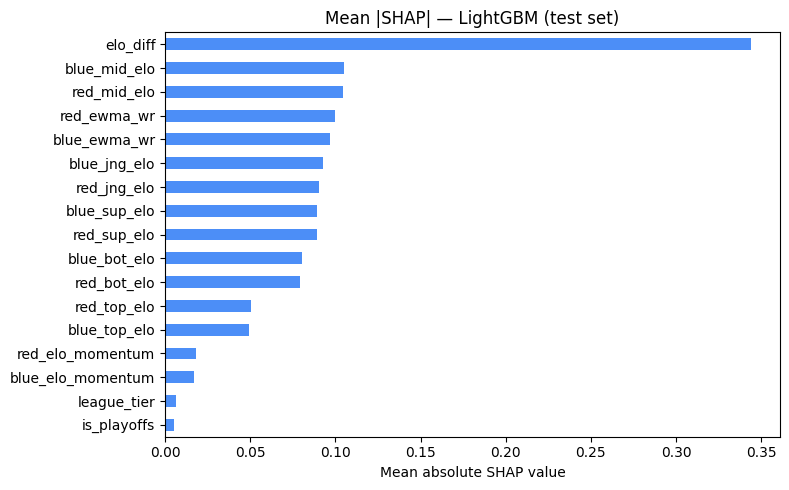

In [11]:
import shap
from sklearn.calibration import calibration_curve

# Build a combined test frame with all predictions attached
test_analysis = eval_test.copy().reset_index(drop=True)
test_analysis["proba_elo"]      = elo_proba
test_analysis["proba_xgb"]      = xgb_proba
test_analysis["proba_lgbm"]     = lgbm_proba
test_analysis["proba_gnn"]      = gnn_proba
test_analysis["proba_meta"]     = meta_proba
if tabpfn_proba is not None:
    test_analysis["proba_tabpfn"] = tabpfn_proba

MAIN = "proba_meta"   # model used for most breakdowns

# ── 9a. Confidence stratification ────────────────────────────────────────────
# Shows accuracy per predicted-confidence bin.
# A well-calibrated model: 70% confidence bin → ~70% accuracy.
print("=" * 65)
print("9a. Confidence stratification (meta-learner)")
print("=" * 65)
bins = [(0.50, 0.55), (0.55, 0.60), (0.60, 0.65), (0.65, 0.70), (0.70, 1.01)]
rows_conf = []
for lo, hi in bins:
    # Use symmetric: 50-55% confident also includes the 45-50% range (same certainty, other side)
    mask = (test_analysis[MAIN] >= lo) & (test_analysis[MAIN] < hi)
    mask |= (test_analysis[MAIN] >= (1-hi)) & (test_analysis[MAIN] < (1-lo))
    sub = test_analysis[mask]
    if len(sub) == 0:
        continue
    # "Correct" = model picked the right winner
    correct = ((sub[MAIN] > 0.5) == sub["blue_win"].astype(bool)).mean()
    label = f"{lo:.0%}–{hi:.0%}" if hi <= 1.0 else f"{lo:.0%}+"
    rows_conf.append({"confidence": label, "n_games": len(sub), "accuracy": round(correct, 3)})

df_conf = pd.DataFrame(rows_conf)
print(df_conf.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(df_conf["confidence"], df_conf["accuracy"], color="#4c8ef7", width=0.5)
ax.axhline(0.5, color="gray", ls="--", lw=1, label="random")
for i, row in df_conf.iterrows():
    ax.text(i, row["accuracy"] + 0.005, f'n={row["n_games"]}', ha="center", fontsize=8)
ax.set_ylim(0.45, 1.0)
ax.set_xlabel("Model confidence (both sides)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by confidence level")
ax.legend()
plt.tight_layout(); plt.show()

# ── 9b. Per-league breakdown ──────────────────────────────────────────────────
print("\n" + "=" * 65)
print("9b. Per-league performance (meta-learner, min 30 games)")
print("=" * 65)
league_rows = []
for league, grp in test_analysis.groupby("league"):
    if len(grp) < 30:
        continue
    y_l = grp["blue_win"].values
    p_l = grp[MAIN].values
    league_rows.append({
        "league":   league,
        "n_games":  len(grp),
        "accuracy": round(accuracy_score(y_l, p_l > 0.5), 3),
        "roc_auc":  round(roc_auc_score(y_l, p_l), 3) if len(np.unique(y_l)) > 1 else np.nan,
        "brier":    round(brier_score_loss(y_l, p_l), 4),
        "blue_wr":  round(y_l.mean(), 3),
    })
df_league = pd.DataFrame(league_rows).sort_values("roc_auc", ascending=False)
print(df_league.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes, ["accuracy", "roc_auc"], ["Accuracy", "ROC-AUC"]):
    vals = df_league.set_index("league")[col].sort_values()
    colors = ["#3fb950" if v >= vals.median() else "#f85149" for v in vals]
    ax.barh(vals.index, vals.values, color=colors)
    ax.axvline(vals.median(), color="gray", ls="--", lw=1)
    ax.set_title(f"{title} by league")
    ax.set_xlabel(col)
plt.tight_layout(); plt.show()

# ── 9c. Elo differential analysis ────────────────────────────────────────────
print("\n" + "=" * 65)
print("9c. Performance by Elo differential (quartiles)")
print("=" * 65)
test_analysis["elo_diff_abs"] = test_analysis["elo_diff"].abs()
test_analysis["elo_quartile"] = pd.qcut(test_analysis["elo_diff_abs"], q=4,
                                         labels=["Q1 close", "Q2", "Q3", "Q4 dominant"])
elo_rows = []
for q, grp in test_analysis.groupby("elo_quartile", observed=True):
    y_q = grp["blue_win"].values
    elo_rows.append({
        "elo_diff_range": f"{grp['elo_diff_abs'].min():.0f}–{grp['elo_diff_abs'].max():.0f}",
        "quartile": q,
        "n_games":  len(grp),
        "elo_acc":  round(accuracy_score(y_q, grp["proba_elo"] > 0.5), 3),
        "meta_acc": round(accuracy_score(y_q, grp[MAIN] > 0.5), 3),
        "meta_auc": round(roc_auc_score(y_q, grp[MAIN]), 3) if len(np.unique(y_q)) > 1 else np.nan,
    })
df_elo = pd.DataFrame(elo_rows)
print(df_elo.to_string(index=False))
print("\nIf meta_acc > elo_acc in Q1 (close games), the model adds real signal beyond Elo.")

# ── 9d. Playoffs vs regular season ───────────────────────────────────────────
print("\n" + "=" * 65)
print("9d. Playoffs vs Regular Season")
print("=" * 65)
for label, mask in [("Regular season", test_analysis["is_playoffs"] == 0),
                    ("Playoffs",        test_analysis["is_playoffs"] == 1)]:
    grp = test_analysis[mask]
    if len(grp) < 10:
        continue
    y_g = grp["blue_win"].values
    p_g = grp[MAIN].values
    print(f"  {label:<18}  n={len(grp):4d}  acc={accuracy_score(y_g, p_g>0.5):.3f}"
          f"  auc={roc_auc_score(y_g, p_g):.3f}  brier={brier_score_loss(y_g, p_g):.4f}")

# ── 9e. Temporal drift ───────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("9e. Temporal drift — accuracy by month")
print("=" * 65)
test_analysis["month"] = pd.to_datetime(test_analysis["date"]).dt.to_period("M")
month_rows = []
for month, grp in test_analysis.groupby("month"):
    if len(grp) < 20:
        continue
    y_m = grp["blue_win"].values
    p_m = grp[MAIN].values
    month_rows.append({"month": str(month), "n": len(grp),
                        "accuracy": round(accuracy_score(y_m, p_m > 0.5), 3),
                        "auc":      round(roc_auc_score(y_m, p_m), 3) if len(np.unique(y_m))>1 else np.nan})
df_month = pd.DataFrame(month_rows)
print(df_month.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df_month["month"], df_month["accuracy"], marker="o", color="#4c8ef7", label="Accuracy")
ax.plot(df_month["month"], df_month["auc"],      marker="s", color="#3ab073", label="AUC")
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set_xticklabels(df_month["month"], rotation=45, ha="right")
ax.set_title("Accuracy / AUC over the test period (temporal drift)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 9f. Biggest upsets — model most confidently wrong ────────────────────────
print("\n" + "=" * 65)
print("9f. Top-20 biggest upsets (model most confident, most wrong)")
print("=" * 65)
test_analysis["correct"]    = (test_analysis[MAIN] > 0.5) == test_analysis["blue_win"].astype(bool)
test_analysis["confidence"] = (test_analysis[MAIN] - 0.5).abs()
upsets = test_analysis[~test_analysis["correct"]].nlargest(20, "confidence")
print(upsets[["date", "league", "blue_team", "red_team", MAIN, "blue_win",
              "elo_diff", "is_playoffs"]].rename(columns={MAIN: "pred_prob"}).to_string(index=False))

# ── 9g. SHAP feature importance (LightGBM) ───────────────────────────────────
print("\n" + "=" * 65)
print("9g. SHAP feature importance — LightGBM")
print("=" * 65)
X_test_df = pd.DataFrame(X_test, columns=FEATURE_COLS)
explainer_shap = shap.TreeExplainer(lgbm)
shap_vals = explainer_shap.shap_values(X_test_df)
# For binary classification shap returns list [class0, class1]; take class1
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
mean_abs = np.abs(sv).mean(axis=0)
feat_imp = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
print(feat_imp.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.sort_values().plot.barh(ax=ax, color="#4c8ef7")
ax.set_title("Mean |SHAP| — LightGBM (test set)")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout(); plt.show()


## 8. Team Strength Visualisation — Elo Rankings

Starting ratings are seeded by league tier (LCK=1620, LPL=1600, LEC=1530, … PRM=1380), so teams from stronger leagues begin higher and cross-league comparisons are meaningful.

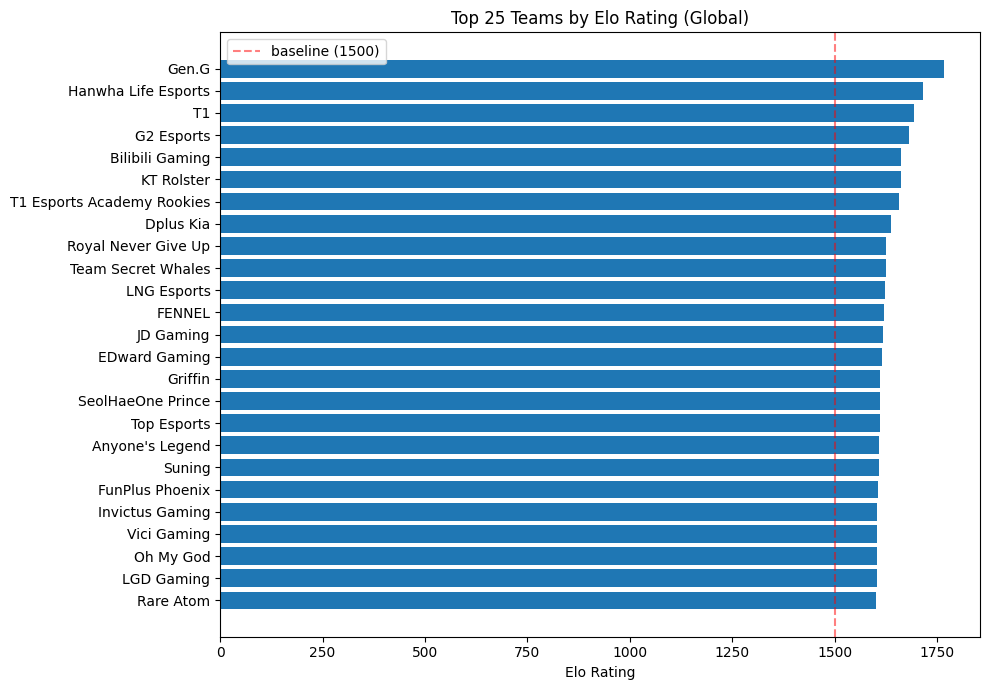

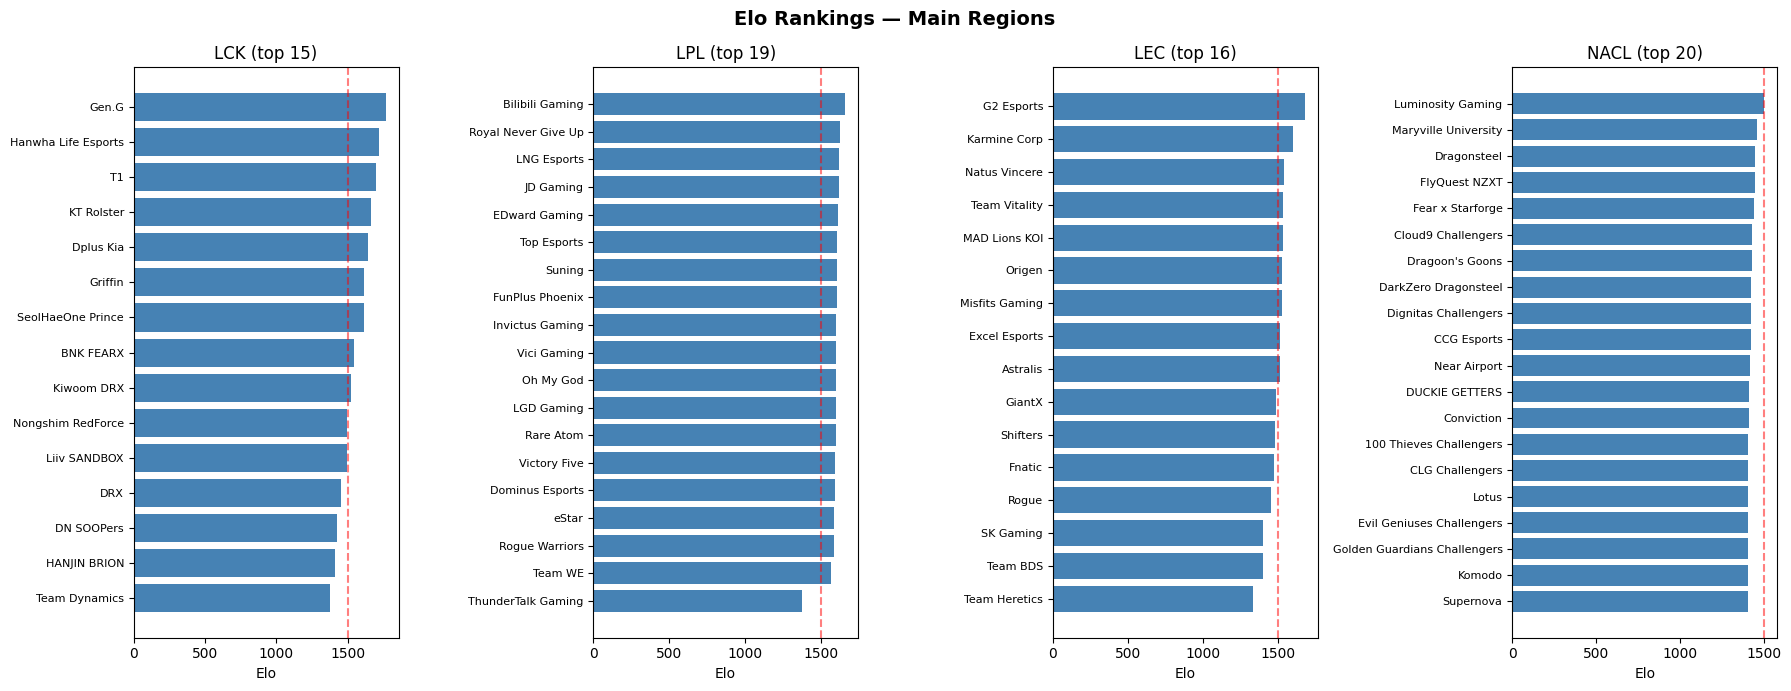


Main-region Elo rankings:
league                         team         elo  games
   LCK                        Gen.G 1766.813986    826
   LCK          Hanwha Life Esports 1715.819338    766
   LCK                           T1 1694.735473    920
   LCK                   KT Rolster 1661.861549    705
   LCK                    Dplus Kia 1637.844210    846
   LCK                      Griffin 1612.034269     83
   LCK            SeolHaeOne Prince 1611.174408     83
   LCK                    BNK FEARX 1542.315764    285
   LCK                   Kiwoom DRX 1518.921347     53
   LCK            Nongshim RedForce 1492.878052    564
   LCK                 Liiv SANDBOX 1491.898623    390
   LCK                          DRX 1449.034791    634
   LCK                   DN SOOPers 1424.985377    617
   LCK                 HANJIN BRION 1411.974036    581
   LCK                Team Dynamics 1373.921740     87
   LEC                   G2 Esports 1681.840222    596
   LEC                 Karmine Corp 16

In [14]:
elo_rankings = (
    pd.Series(elo._ratings, name="elo")
    .reset_index()
    .rename(columns={"index": "team"})
    .sort_values("elo", ascending=False)
)

# Require minimum games so cold-start teams don't appear
game_counts = (
    pd.concat([game_df["blue_team"], game_df["red_team"]])
    .value_counts()
)
elo_rankings["games"] = elo_rankings["team"].map(game_counts).fillna(0).astype(int)
elo_rankings = elo_rankings[elo_rankings["games"] >= 20].reset_index(drop=True)

# ── Global Top 25 ─────────────────────────────────────────────────────────────
top25 = elo_rankings.head(25)
plt.figure(figsize=(10, 7))
plt.barh(top25["team"].iloc[::-1], top25["elo"].iloc[::-1])
plt.axvline(1500, color="red", linestyle="--", alpha=0.5, label="baseline (1500)")
plt.xlabel("Elo Rating")
plt.title(f"Top {len(top25)} Teams by Elo Rating (Global)")
plt.legend()
plt.tight_layout()
plt.show()

# ── Per-team primary league (most recent league they played in) ───────────────
# Stack blue/red into long format with league
team_league = pd.concat([
    game_df[["blue_team", "league", "date"]].rename(columns={"blue_team": "team"}),
    game_df[["red_team",  "league", "date"]].rename(columns={"red_team":  "team"}),
], ignore_index=True)
# Primary league = league with most games for that team
primary_league = (
    team_league.groupby(["team", "league"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .drop_duplicates(subset="team")
    .set_index("team")["league"]
)
elo_rankings["league"] = elo_rankings["team"].map(primary_league)

# ── Filtered: LEC / LCK / LPL / NACL ────────────────────────────────────────
MAIN_LEAGUES = {"LEC", "LCK", "LPL", "NACL"}
main_rankings = elo_rankings[elo_rankings["league"].isin(MAIN_LEAGUES)].copy()

fig, axes = plt.subplots(1, len(MAIN_LEAGUES), figsize=(18, 7), sharey=False)
for ax, lg in zip(axes, ["LCK", "LPL", "LEC", "NACL"]):
    subset = main_rankings[main_rankings["league"] == lg].head(20)
    if subset.empty:
        ax.set_title(lg)
        continue
    ax.barh(subset["team"].iloc[::-1], subset["elo"].iloc[::-1], color="steelblue")
    ax.axvline(1500, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("Elo")
    ax.set_title(f"{lg} (top {len(subset)})")
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Elo Rankings — Main Regions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Printable table ───────────────────────────────────────────────────────────
print("\nMain-region Elo rankings:")
print(main_rankings[["league", "team", "elo", "games"]]
      .sort_values(["league", "elo"], ascending=[True, False])
      .to_string(index=False))
